# LIBD

In [1]:
import os, glob, sys, time, gc

# — os, glob, sys: file‐ and path‐handling; time for measuring durations.
# — glob for matching “*-annotated_matrix.txt” files.

sys.path.insert(0, "../")
# — so Python can import your local scGPT repo and build_index script.

os.environ["KMP_WARNINGS"] = "off"
os.environ["WANDB_NOTEBOOK_NAME"] = "scgpt_finetune.ipynb"

import warnings

warnings.filterwarnings('ignore')
# — suppress extra warnings from MKL/OpenMP and other libs.

import numpy as np  # array ops
import pandas as pd  # tabular I/O/manipulation
import anndata as ad  # AnnData container
from anndata import AnnData

import scanpy as sc  # single-cell toolkit

sc.set_figure_params(figsize=(6, 6))  # default plot size

import scgpt as scg  # the scGPT package
from scgpt.model import TransformerModel, AdversarialDiscriminator
# — used later in the Annotation workflow

from scgpt.tokenizer import tokenize_and_pad_batch, random_mask_value
# — for building training data in Annotation

from scgpt.loss import (
    masked_mse_loss,
    masked_relative_error,
    criterion_neg_log_bernoulli,
)
# — losses used in fine-tuning

from scgpt.tokenizer.gene_tokenizer import GeneVocab
# — maps gene names ↔ token IDs

from scgpt.preprocess import Preprocessor
# — handles normalization, HVG selection, binning

from scgpt import SubsetsBatchSampler
# — for balanced batch sampling during Annotation

from scgpt.utils import set_seed, category_str2int, eval_scib_metrics
# — reproducibility, label encoding, integration metrics

import faiss  # similarity search for Reference Mapping
from build_atlas_index_faiss import load_index, vote
from tqdm import tqdm  # progress bars

# misc utilities
import copy, gc, json
from pathlib import Path
import shutil, traceback
from typing import List, Tuple, Dict, Union, Optional
import pickle, torch, scvi, seaborn as sns, wandb
from scipy.sparse import issparse
import matplotlib.pyplot as plt
from torch import nn, Tensor
import torch.nn.functional as F
import entmax as E
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, adjusted_rand_score, \
    normalized_mutual_info_score, confusion_matrix
from torchtext.vocab import Vocab
from torchtext._torchtext import Vocab as VocabPybind


Global seed set to 0


In [2]:
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()


In [3]:
input_dir = "../data/snrna_expr_matrices/LIBD"
output_dir = input_dir
model_dir = "../save/scGPT_human"

pattern = os.path.join(input_dir, "*-annotated_matrix.txt")
cell_type_key = "celltype"
gene_col = "gene_name"


In [4]:
num_txt = 0
ads = []

for path in glob.glob(pattern):
    df = pd.read_csv(path, sep="\t", index_col=0)
    adata = ad.AnnData(
        X=df.T.values,
        obs=pd.DataFrame(index=df.T.index),
        var=pd.DataFrame(index=df.T.columns),
        dtype=df.values.dtype,
    )
    sample = os.path.basename(path).split("-")[0]
    adata.obs["sample_id"] = sample
    adata.obs_names = [f"{cell}.{sample}" for cell in adata.obs_names]
    ads.append(adata)
    print(f"  - Converted {os.path.basename(path)}")

    num_txt = num_txt + 1
    if num_txt == 3:
        break


  - Converted Br2743-annotated_matrix.txt
  - Converted Br6423-annotated_matrix.txt
  - Converted Br8492-annotated_matrix.txt


In [5]:
adata = ad.concat(ads, join="outer", fill_value=0)
adata.obs["celltype"] = adata.obs_names.str.split(".", n=1).str[0].astype("category")
adata.var["gene_name"] = adata.var.index
adata.var.set_index("gene_name", drop=False, inplace=True)

print(adata)


AnnData object with n_obs × n_vars = 13764 × 33783
    obs: 'sample_id', 'celltype'
    var: 'gene_name'


In [6]:
print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")

if "sample_id" in adata.obs:
    sample_counts = adata.obs["sample_id"].value_counts()
    print(f"Number of samples: {sample_counts.index.nunique()}")
    print("Cells per sample:")
    print(sample_counts)
else:
    print("No `sample_id` column found in adata.obs")

print("First 5 cells:", adata.obs_names[:5].tolist())
print("First 5 genes:", adata.var_names[:5].tolist())


Number of cells: 13764
Number of genes: 33783
Number of samples: 3
Cells per sample:
Br2743    4969
Br6423    4451
Br8492    4344
Name: sample_id, dtype: int64
First 5 cells: ['L5 IT.Br2743', 'L6 IT.Br2743', 'L6 IT.1.Br2743', 'L6 IT.2.Br2743', 'L5 IT.1.Br2743']
First 5 genes: ['MIR1302-2HG', 'AL627309.1', 'AL627309.3', 'AL627309.5', 'AP006222.2']


In [7]:
adata.write_h5ad(os.path.join(output_dir, "LIBD.h5ad"))
print(f"Wrote LIBD.h5ad to {output_dir}")

adata.write_zarr(os.path.join(output_dir, "LIBD.zarr"))
print(f"Wrote LIBD.zarr to {output_dir}")


Wrote LIBD.h5ad to ../data/snrna_expr_matrices/LIBD
Wrote LIBD.zarr to ../data/snrna_expr_matrices/LIBD


In [8]:
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()


## RM


In [10]:
adata = sc.read_h5ad(os.path.join(output_dir, "LIBD.h5ad"))

# # Backed: Save ram
# # adata = ad.read_zarr(os.path.join(output_dir, "LIBD.zarr"))
# backed_adata = sc.read_h5ad(os.path.join(output_dir, "LIBD.h5ad"), backed="r+")

# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)
#
# sc.pp.highly_variable_genes(adata, n_top_genes=3000)
# adata = adata[:, adata.var.highly_variable]

preprocessor = Preprocessor(
    use_key="X",
    normalize_total=1e4,
    result_normed_key="X_normed",
    log1p=True,
    result_log1p_key="X_log1p",
    # # Backed: Save ram
    # subset_hvg=None,
    subset_hvg=3000,
    hvg_flavor="seurat_v3",
)

# # Backed: Manual chunk_size
# n_cells = backed_adata.n_obs
# chunk_size = 5000
# chunks = []
#
# for start in range(0, n_cells, chunk_size):
#     end = min(start + chunk_size, n_cells)
#     chunk = backed_adata[start:end, :].to_memory()
#     preprocessor(chunk)
#     chunks.append(chunk)
#     print(f"Loaded and preprocessed chunk {start} - {end} to memory: {end - start}")

# # Backed: Dataset with simple ID
# chunks = []
#
# for sample in backed_adata.obs["sample_id"].cat.categories:
#     sub = backed_adata[backed_adata.obs["sample_id"] == sample, :].to_memory()
#     # preprocessor(sub)
#     chunks.append(sub)
#     print(f"Loaded and preprocessed chunk {sample} to memory: {len(sub)}")
#
# adata = ad.concat(
#     chunks,
#     join="outer",
# )
# sc.pp.highly_variable_genes(
#     adata,
#     n_top_genes=3000,
#     flavor="seurat_v3",
#     subset=True,
# )

# # Backed: Save ram
# adata.var[gene_col] = adata.var.index

preprocessor(adata)
adata.X = adata.layers["X_log1p"]


scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Subsetting highly variable genes ...
scGPT - WARNING - No batch_key is provided, will use all cells for HVG selection.


In [11]:
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()


In [12]:
libd_embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    obs_to_save=cell_type_key,
    batch_size=64,
    return_new_adata=True,
)

use_gpu = faiss.get_num_gpus() > 0
index, meta_labels = load_index(
    index_dir="../save/CellXGene_faiss_index",
    use_config_file=False,
    use_gpu=use_gpu
)

print(f"Loaded index with {index.ntotal} cells")


scGPT - INFO - match 2210/3000 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 216/216 [00:06<00:00, 33.12it/s] 


Loading index and meta from ../save/CellXGene_faiss_index ...
Index loaded, num_embeddings: 35096827
Set nprobe from 128 to 128 for 16384 clusters
Loaded index with 35096827 cells


In [13]:
libd_embed_adata.write_h5ad(os.path.join(output_dir, "LIBD_embed.h5ad"))
print(f"Wrote LIBD_embed.h5ad to {output_dir}")


Wrote LIBD_embed.h5ad to ../data/snrna_expr_matrices/LIBD


In [14]:
k = 50
libd_embed = libd_embed_adata.X.astype("float32")
distances, idx = index.search(libd_embed, k)


In [15]:
predict_labels = meta_labels[idx]  # shape: (n_cells, k)

voting = []
for preds in tqdm(predict_labels):
    voting.append(vote(preds, return_prob=False)[0])
voting = np.array(voting)

print(voting[:10])


100%|██████████| 13764/13764 [00:00<00:00, 81836.83it/s]

['L2/3-6 intratelencephalic projecting glutamatergic cortical neuron'
 'L2/3-6 intratelencephalic projecting glutamatergic cortical neuron'
 'L2/3-6 intratelencephalic projecting glutamatergic cortical neuron'
 'neuron'
 'L2/3-6 intratelencephalic projecting glutamatergic cortical neuron'
 'glutamatergic neuron' 'L6b glutamatergic cortical neuron'
 'glutamatergic neuron' 'neuron' 'neuron']


In [16]:
libd_embed_adata.obs["scgpt_ref_map"] = voting
libd_embed_adata.obs[["scgpt_ref_map"]].to_csv(
    os.path.join(output_dir, "libd_scgpt_reference_mapping.csv")
)


In [17]:
sc.pp.neighbors(libd_embed_adata, use_rep="X")
sc.tl.umap(libd_embed_adata)


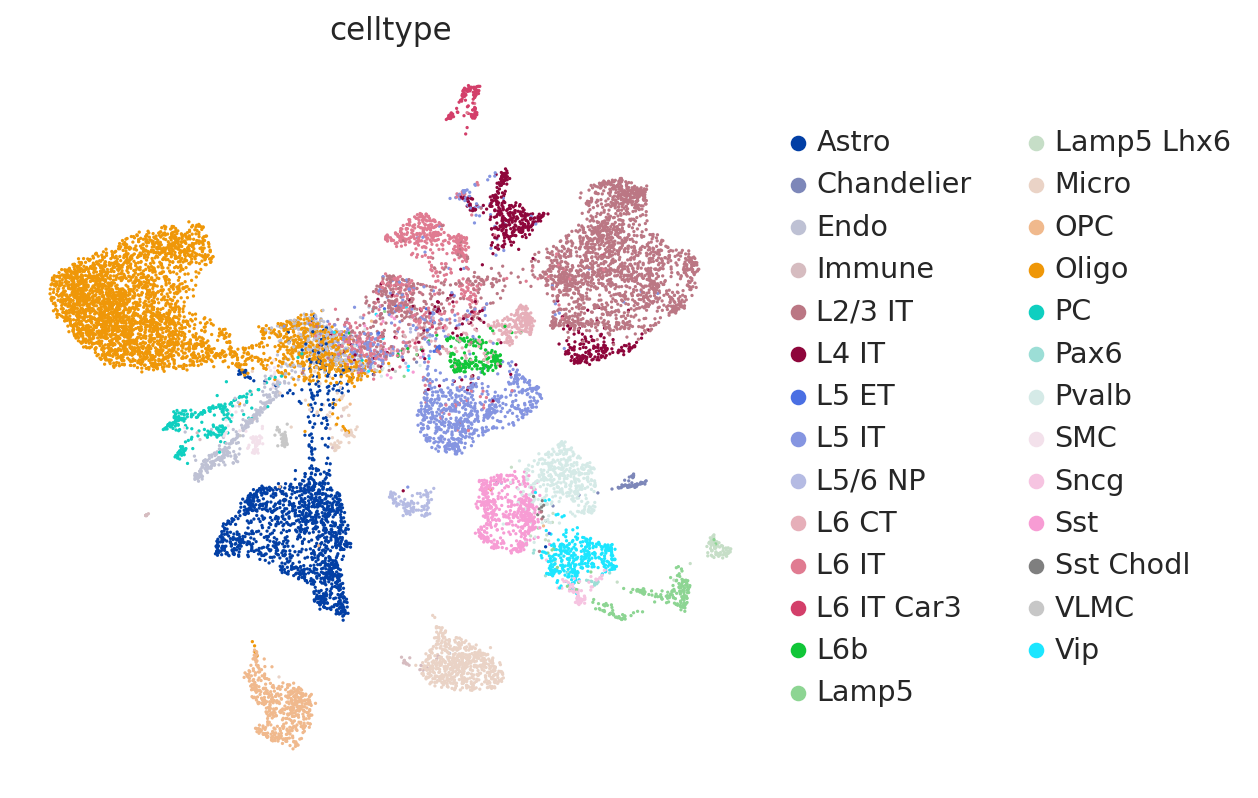

In [18]:
sc.pl.umap(libd_embed_adata, color=cell_type_key, frameon=False, wspace=0.4)


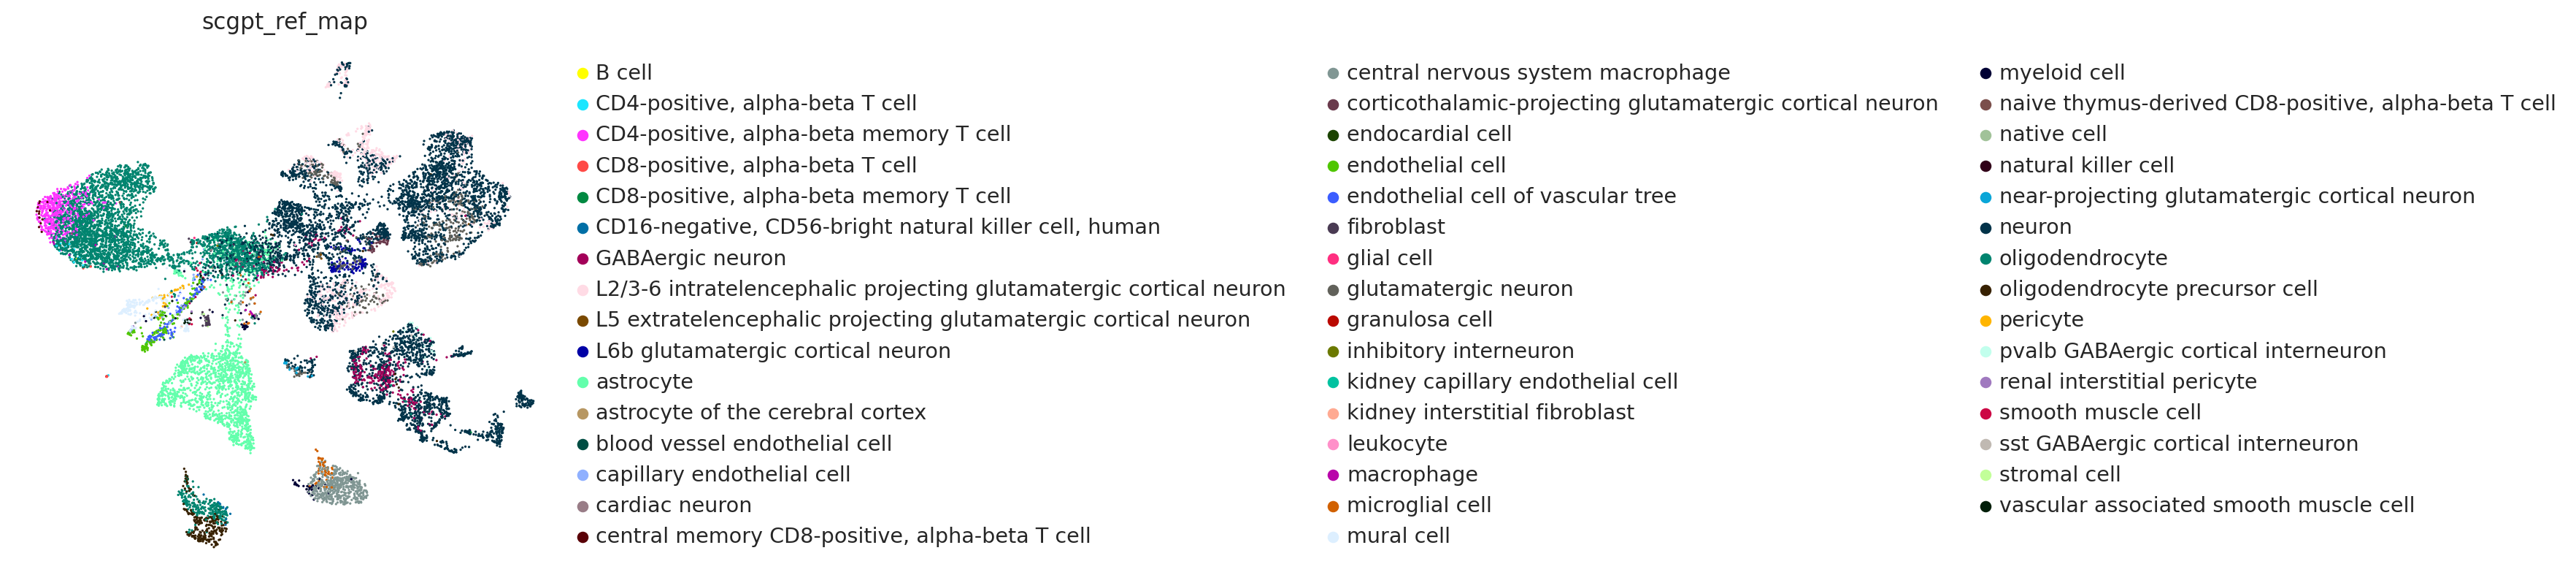

In [19]:
sc.pl.umap(libd_embed_adata, color="scgpt_ref_map", frameon=False, wspace=0.4)


In [20]:
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()


## A

In [4]:
# adata = sc.read_h5ad(os.path.join(output_dir, "LIBD.h5ad"))

# Backed: Save ram
# adata = ad.read_zarr(os.path.join(output_dir, "LIBD.zarr"))
backed_adata = sc.read_h5ad(os.path.join(output_dir, "LIBD.h5ad"), backed="r+")

# # Backed: Manual chunk_size
# n_cells = backed_adata.n_obs
# chunk_size = 5000
# chunks = []
#
# for start in range(0, n_cells, chunk_size):
#     end = min(start + chunk_size, n_cells)
#     chunk = backed_adata[start:end, :].to_memory()
#     chunks.append(chunk)
#     print(f"Loaded chunk {start} - {end} to memory: {end - start}")

# Backed: Dataset with simple ID
chunks = []

for sample in backed_adata.obs["sample_id"].cat.categories:
    sub = backed_adata[backed_adata.obs["sample_id"] == sample, :].to_memory()
    chunks.append(sub)
    print(f"Loaded chunk {sample} to memory: {len(sub)}")

adata = ad.concat(
    chunks,
    join="outer",
)

# Backed: Save ram
adata.var[gene_col] = adata.var.index

filter_gene_by_counts = False
data_is_raw = True


Loaded chunk Br2743 to memory: 4969
Loaded chunk Br6423 to memory: 4451
Loaded chunk Br8492 to memory: 4344


In [5]:
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()


In [6]:
hyperparameter_defaults = dict(
    seed=0,
    dataset_name="LIBD",
    do_train=True,
    load_model="../save/scGPT_human",
    mask_ratio=0.0,
    epochs=10,
    n_bins=51,
    # MVC=True
    MVC=False,  # no masked‐value regression
    ecs_thres=0.0,  # no elastic‐similarity loss
    dab_weight=0.0,  # no domain‐adaptation loss
    lr=1e-4,
    # lr=2e-5
    batch_size=32,
    # batch_size=16,
    layer_size=128,
    nlayers=4,  # 4 TransformerEncoder layers in your new classification head
    nhead=4,
    dropout=0.2,
    schedule_ratio=0.9,
    save_eval_interval=5,
    fast_transformer=True,
    pre_norm=False,
    amp=True,
    include_zero_gene=False,
    freeze=False,
    # freeze=True,
    DSBN=False,  # no domain‐specific batchnorm
)


In [7]:
run = wandb.init(
    config=hyperparameter_defaults,
    project="scGPT",
    reinit='finish_previous',
    settings=wandb.Settings(start_method="fork"),
)

config = wandb.config
print(config)

set_seed(config.seed)


wandb: Currently logged in as: yhu116 (apex_1465) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


{'seed': 0, 'dataset_name': 'LIBD', 'do_train': True, 'load_model': '../save/scGPT_human', 'mask_ratio': 0.0, 'epochs': 10, 'n_bins': 51, 'MVC': False, 'ecs_thres': 0.0, 'dab_weight': 0.0, 'lr': 0.0001, 'batch_size': 32, 'layer_size': 128, 'nlayers': 4, 'nhead': 4, 'dropout': 0.2, 'schedule_ratio': 0.9, 'save_eval_interval': 5, 'fast_transformer': True, 'pre_norm': False, 'amp': True, 'include_zero_gene': False, 'freeze': False, 'DSBN': False}


In [8]:
# settings for input and preprocessing
pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]
mask_ratio = config.mask_ratio
mask_value = "auto"  # for masked values, now it should always be auto

include_zero_gene = config.include_zero_gene  # if True, include zero genes among hvgs in the training
max_seq_len = 3001
n_bins = config.n_bins

# input/output representation
input_style = "binned"  # "normed_raw", "log1p", or "binned"
output_style = "binned"  # "normed_raw", "log1p", or "binned"

# settings for training
MLM = False  # whether to use masked language modeling, currently it is always on.
CLS = True  # celltype classification objective
ADV = False  # Adversarial training for batch correction
CCE = False  # Contrastive cell embedding objective
MVC = config.MVC  # Masked value prediction for cell embedding
ECS = config.ecs_thres > 0  # Elastic cell similarity objective
# DAB = 2
DAB = False  # Domain adaptation by reverse backpropagation, set to 2 for separate optimizer
INPUT_BATCH_LABELS = False  # TODO: have these help MLM and MVC, while not to classifier
input_emb_style = "continuous"  # "category" or "continuous" or "scaling"
cell_emb_style = "cls"  # "avg-pool" or "w-pool" or "cls"
adv_E_delay_epochs = 0  # delay adversarial training on encoder for a few epochs
adv_D_delay_epochs = 0
mvc_decoder_style = "inner product"
ecs_threshold = config.ecs_thres
dab_weight = config.dab_weight

explicit_zero_prob = MLM and include_zero_gene  # whether explicit bernoulli for zeros
do_sample_in_train = False and explicit_zero_prob  # sample the bernoulli in training

per_seq_batch_sample = False

# settings for optimizer
lr = config.lr  # TODO: test learning rate ratio between two tasks
lr_ADV = 1e-3  # learning rate for discriminator, used when ADV is True
batch_size = config.batch_size
eval_batch_size = config.batch_size
epochs = config.epochs
schedule_interval = 1

# settings for the model
fast_transformer = config.fast_transformer
fast_transformer_backend = "flash"  # "linear" or "flash"
embsize = config.layer_size  # embedding dimension
d_hid = config.layer_size  # dimension of the feedforward network in TransformerEncoder
nlayers = config.nlayers  # number of TransformerEncoderLayer in TransformerEncoder
nhead = config.nhead  # number of heads in nn.MultiheadAttention
dropout = config.dropout  # dropout probability

# logging
log_interval = 100  # iterations
save_eval_interval = config.save_eval_interval  # epochs
do_eval_scib_metrics = True


In [9]:
# %% validate settings
assert input_style in ["normed_raw", "log1p", "binned"]
assert output_style in ["normed_raw", "log1p", "binned"]
assert input_emb_style in ["category", "continuous", "scaling"]
if input_style == "binned":
    if input_emb_style == "scaling":
        raise ValueError("input_emb_style `scaling` is not supported for binned input.")
elif input_style == "log1p" or input_style == "normed_raw":
    if input_emb_style == "category":
        raise ValueError(
            "input_emb_style `category` is not supported for log1p or normed_raw input."
        )

if input_emb_style == "category":
    mask_value = n_bins + 1
    pad_value = n_bins  # for padding gene expr values
    n_input_bins = n_bins + 2
else:
    mask_value = -1
    pad_value = -2
    n_input_bins = n_bins

if ADV and DAB:
    raise ValueError("ADV and DAB cannot be both True.")
DAB_separate_optim = True if DAB > 1 else False


In [10]:
dataset_name = config.dataset_name
save_dir = Path(f"../save/dev_{dataset_name}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"save to {save_dir}")
logger = scg.logger
scg.utils.add_file_handler(logger, save_dir / "run.log")


save to ../save/dev_LIBD-Aug01-14-34


In [11]:
idx_train, idx_test = train_test_split(
    np.arange(adata.n_obs),
    train_size=0.9,
    shuffle=True,
)
adata_train = adata[idx_train]
adata_train.obs["str_batch"] = "0"
adata_train.var.set_index(adata.var["gene_name"], inplace=True)
adata_test = adata[idx_test]
adata_test.obs["str_batch"] = "1"
adata_test.var.set_index(adata.var["gene_name"], inplace=True)
adata_test_raw = adata_test.copy()

adata_all = adata_train.concatenate(
    adata_test,
    batch_key="str_batch",
)

adata_all.obs["batch_id"] = adata_all.obs["str_batch"].astype("category").cat.codes.values
adata_all.obs["celltype_id"] = adata_all.obs["celltype"].astype("category").cat.codes.values
celltypes = adata_all.obs["celltype"].astype("category").cat.categories.tolist()
num_types = len(celltypes)
id2type = dict(enumerate(celltypes))
adata_all.var["gene_name"] = adata_all.var.index


In [12]:
adata_all.obs["celltype"][:5]


Oligo.718.Br6423-0        Oligo
L2/3 IT.302.Br6423-0    L2/3 IT
L2/3 IT.776.Br8492-0    L2/3 IT
Oligo.306.Br2743-0        Oligo
L2/3 IT.194.Br6423-0    L2/3 IT
Name: celltype, dtype: category
Categories (27, object): ['Astro', 'Chandelier', 'Endo', 'Immune', ..., 'Sst', 'Sst Chodl', 'VLMC', 'Vip']

In [13]:
if config.load_model is not None:
    model_dir = Path(config.load_model)
    model_config_file = model_dir / "args.json"
    model_file = model_dir / "best_model.pt"
    vocab_file = model_dir / "vocab.json"

    vocab = GeneVocab.from_file(vocab_file)
    shutil.copy(vocab_file, save_dir / "vocab.json")
    for s in special_tokens:
        if s not in vocab:
            vocab.append_token(s)

    adata_all.var["id_in_vocab"] = [
        1 if gene in vocab else -1 for gene in adata_all.var["gene_name"]
    ]
    gene_ids_in_vocab = np.array(adata_all.var["id_in_vocab"])
    logger.info(
        f"match {np.sum(gene_ids_in_vocab >= 0)}/{len(gene_ids_in_vocab)} genes "
        f"in vocabulary of size {len(vocab)}."
    )
    adata_all = adata_all[:, adata_all.var["id_in_vocab"] >= 0]

    # model
    with open(model_config_file, "r") as f:
        model_configs = json.load(f)
    logger.info(
        f"Resume model from {model_file}, the model args will override the "
        f"config {model_config_file}."
    )
    embsize = model_configs["embsize"]
    nhead = model_configs["nheads"]
    d_hid = model_configs["d_hid"]
    nlayers = model_configs["nlayers"]
    n_layers_cls = model_configs["n_layers_cls"]


scGPT - INFO - match 22022/33783 genes in vocabulary of size 60697.
scGPT - INFO - Resume model from ../save/scGPT_human/best_model.pt, the model args will override the config ../save/scGPT_human/args.json.


In [14]:
preprocessor = Preprocessor(
    use_key="X",
    filter_gene_by_counts=filter_gene_by_counts,
    filter_cell_by_counts=False,
    normalize_total=1e4,
    result_normed_key="X_normed",
    log1p=data_is_raw,
    result_log1p_key="X_log1p",
    subset_hvg=False,
    hvg_flavor="seurat_v3" if data_is_raw else "cell_ranger",
    binning=n_bins,
    result_binned_key="X_binned",
)

adata_train = adata_all[adata_all.obs["str_batch"] == "0"]
adata_test = adata_all[adata_all.obs["str_batch"] == "1"]

# # Backed: Manual chunk_size
# n_cells_train = adata_train.n_obs
# n_cells_test = adata_test.n_obs
# chunk_size_train = 5000
# chunk_size_test = 1000
# chunks_train = []
# chunks_test = []
#
# for start in range(0, n_cells_train, chunk_size_train):
#     end = min(start + chunk_size_train, n_cells_train)
#     chunk = backed_adata_train[start:end, :]
#     preprocessor(chunk)
#     chunks_train.append(chunk)
#     print(f"Loaded and preprocessed chunk {start} - {end} to memory: {end - start}")
#
# adata_train = ad.concat(
#     chunks_train,
#     join="outer",
# )
#
# for start in range(0, n_cells_test, chunk_size_test):
#     end = min(start + chunk_size_test, n_cells_test)
#     chunk = adata_test[start:end, :]
#     preprocessor(chunk)
#     chunks_test.append(chunk)
#     print(f"Loaded and preprocessed chunk {start} - {end} to memory: {end - start}")
#
# adata_test = ad.concat(
#     chunks_test,
#     join="outer",
# )

# # Backed: Dataset with simple ID
# chunks_train = []
# chunks_test = []
#
# for sample in adata_train.obs["sample_id"].astype("category").cat.categories:
#     sub = adata_train[adata_train.obs["sample_id"] == sample, :]
#     preprocessor(sub, batch_key=None)
#     chunks_train.append(sub)
#     print(f"Loading chunk {sample} to memory: {len(sub)}")
#
# adata_train = ad.concat(
#     chunks_train,
#     join="outer",
# )
#
# for sample in adata_test.obs["sample_id"].astype("category").cat.categories:
#     sub = adata_test[adata_test.obs["sample_id"] == sample, :]
#     preprocessor(sub, batch_key=None)
#     chunks_test.append(sub)
#     print(f"Loading chunk {sample} to memory: {len(sub)}")
#
# adata_test = ad.concat(
#     chunks_test,
#     join="outer",
# )
#
# # Backed: Save Ram
# adata_train.var[gene_col] = adata_train.var.index
# adata_test.var[gene_col] = adata_test.var.index

preprocessor(adata_train, batch_key=None)
preprocessor(adata_test, batch_key=None)


scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Loading chunk Br2743 to memory: 4483
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Loading chunk Br6423 to memory: 4018
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Loading chunk Br8492 to memory: 3886
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Loading chunk Br2743 to memory: 486
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Loading chunk Br6423 to memory: 433
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Loading chunk Br8492 to memory: 458


In [15]:
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()


In [16]:
input_layer_key = {  # the values of this map coorespond to the keys in preprocessing
    "normed_raw": "X_normed",
    "log1p": "X_normed",
    "binned": "X_binned",
}[input_style]
all_counts = (
    adata_train.layers[input_layer_key].toarray()
    if issparse(adata_train.layers[input_layer_key])
    else adata_train.layers[input_layer_key]
)
genes = adata_train.var["gene_name"].tolist()

celltypes_labels = adata_train.obs["celltype_id"].tolist()  # make sure count from 0
celltypes_labels = np.array(celltypes_labels)

batch_ids = adata_train.obs["batch_id"].tolist()
num_batch_types = len(set(batch_ids))
batch_ids = np.array(batch_ids)

(
    train_data,
    valid_data,
    train_celltype_labels,
    valid_celltype_labels,
    train_batch_labels,
    valid_batch_labels,
) = train_test_split(
    all_counts, celltypes_labels, batch_ids, test_size=0.1, shuffle=True
)


In [17]:
if config.load_model is None:
    vocab = Vocab(
        VocabPybind(genes + special_tokens, None)
    )  # bidirectional lookup [gene <-> int]
vocab.set_default_index(vocab["<pad>"])
gene_ids = np.array(vocab(genes), dtype=int)


In [18]:
tokenized_train = tokenize_and_pad_batch(
    train_data,
    gene_ids,
    max_len=max_seq_len,
    vocab=vocab,
    pad_token=pad_token,
    pad_value=pad_value,
    append_cls=True,  # append <cls> token at the beginning
    include_zero_gene=include_zero_gene,
)
tokenized_valid = tokenize_and_pad_batch(
    valid_data,
    gene_ids,
    max_len=max_seq_len,
    vocab=vocab,
    pad_token=pad_token,
    pad_value=pad_value,
    append_cls=True,
    include_zero_gene=include_zero_gene,
)
logger.info(
    f"train set number of samples: {tokenized_train['genes'].shape[0]}, "
    f"\n\t feature length: {tokenized_train['genes'].shape[1]}"
)
logger.info(
    f"valid set number of samples: {tokenized_valid['genes'].shape[0]}, "
    f"\n\t feature length: {tokenized_valid['genes'].shape[1]}"
)


scGPT - INFO - train set number of samples: 11148, 
	 feature length: 3001
scGPT - INFO - valid set number of samples: 1239, 
	 feature length: 3001


In [19]:
def prepare_data(sort_seq_batch=False) -> Tuple[Dict[str, torch.Tensor]]:
    masked_values_train = random_mask_value(
        tokenized_train["values"],
        mask_ratio=mask_ratio,
        mask_value=mask_value,
        pad_value=pad_value,
    )
    masked_values_valid = random_mask_value(
        tokenized_valid["values"],
        mask_ratio=mask_ratio,
        mask_value=mask_value,
        pad_value=pad_value,
    )
    print(
        f"random masking at epoch {epoch:3d}, ratio of masked values in train: ",
        f"{(masked_values_train == mask_value).sum() / (masked_values_train - pad_value).count_nonzero():.4f}",
    )

    input_gene_ids_train, input_gene_ids_valid = (
        tokenized_train["genes"],
        tokenized_valid["genes"],
    )
    input_values_train, input_values_valid = masked_values_train, masked_values_valid
    target_values_train, target_values_valid = (
        tokenized_train["values"],
        tokenized_valid["values"],
    )

    tensor_batch_labels_train = torch.from_numpy(train_batch_labels).long()
    tensor_batch_labels_valid = torch.from_numpy(valid_batch_labels).long()

    tensor_celltype_labels_train = torch.from_numpy(train_celltype_labels).long()
    tensor_celltype_labels_valid = torch.from_numpy(valid_celltype_labels).long()

    if sort_seq_batch:  # TODO: update to random pick seq source in each traning batch
        train_sort_ids = np.argsort(train_batch_labels)
        input_gene_ids_train = input_gene_ids_train[train_sort_ids]
        input_values_train = input_values_train[train_sort_ids]
        target_values_train = target_values_train[train_sort_ids]
        tensor_batch_labels_train = tensor_batch_labels_train[train_sort_ids]
        tensor_celltype_labels_train = tensor_celltype_labels_train[train_sort_ids]

        valid_sort_ids = np.argsort(valid_batch_labels)
        input_gene_ids_valid = input_gene_ids_valid[valid_sort_ids]
        input_values_valid = input_values_valid[valid_sort_ids]
        target_values_valid = target_values_valid[valid_sort_ids]
        tensor_batch_labels_valid = tensor_batch_labels_valid[valid_sort_ids]
        tensor_celltype_labels_valid = tensor_celltype_labels_valid[valid_sort_ids]

    train_data_pt = {
        "gene_ids": input_gene_ids_train,
        "values": input_values_train,
        "target_values": target_values_train,
        "batch_labels": tensor_batch_labels_train,
        "celltype_labels": tensor_celltype_labels_train,
    }
    valid_data_pt = {
        "gene_ids": input_gene_ids_valid,
        "values": input_values_valid,
        "target_values": target_values_valid,
        "batch_labels": tensor_batch_labels_valid,
        "celltype_labels": tensor_celltype_labels_valid,
    }

    return train_data_pt, valid_data_pt


# dataset
class SeqDataset(Dataset):
    def __init__(self, data: Dict[str, torch.Tensor]):
        self.data = data

    def __len__(self):
        return self.data["gene_ids"].shape[0]

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.data.items()}


# data_loader
def prepare_dataloader(
        data_pt: Dict[str, torch.Tensor],
        batch_size: int,
        shuffle: bool = False,
        intra_domain_shuffle: bool = False,
        drop_last: bool = False,
        num_workers: int = 0,
) -> DataLoader:
    if num_workers == 0:
        num_workers = min(len(os.sched_getaffinity(0)), batch_size // 2)

    dataset = SeqDataset(data_pt)

    if per_seq_batch_sample:
        # find the indices of samples in each seq batch
        subsets = []
        batch_labels_array = data_pt["batch_labels"].numpy()
        for batch_label in np.unique(batch_labels_array):
            batch_indices = np.where(batch_labels_array == batch_label)[0].tolist()
            subsets.append(batch_indices)
        data_loader = DataLoader(
            dataset=dataset,
            batch_sampler=SubsetsBatchSampler(
                subsets,
                batch_size,
                intra_subset_shuffle=intra_domain_shuffle,
                inter_subset_shuffle=shuffle,
                drop_last=drop_last,
            ),
            num_workers=num_workers,
            pin_memory=True,
        )
        return data_loader

    data_loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
    )
    return data_loader


In [20]:
class MoEBlock(nn.Module):
    """
    Wraps one TransformerEncoderLayer with n_experts experts and
    a router that gates on the CLS token.
    """

    def __init__(self, template_layer: nn.Module, n_experts: int = 3):
        super().__init__()
        self.experts = nn.ModuleList(
            [copy.deepcopy(template_layer) for _ in range(n_experts)]
        )
        d_model = template_layer.self_attn.embed_dim
        self.router = nn.Linear(d_model, n_experts, bias=False)
        self.last_gate = None

    def forward(
            self,
            src: Tensor,
            src_mask: Optional[Tensor] = None,
            src_key_padding_mask: Optional[Tensor] = None,
            **kwargs,
    ) -> Tensor:
        # TODO: explicitly assign correct data info to the correct expert
        # TODO: add logger

        # CLS token is index 0 by convention in scGPT
        cls_vec = src[:, 0]  # (B, D)
        # gate = self.router(cls_vec).clamp(-10.0, 10.0)
        gate = self.router(cls_vec)
        # gate = F.softmax(self.router(cls_vec), dim=-1)  # (B, n_experts)
        gate = F.dropout(gate, p=dropout, training=self.training)
        # gate = E.entmax15(gate, dim=-1)
        gate = F.softmax(gate, dim=-1)
        self.last_gate = gate

        expert_outs = [expert(src, src_mask=src_mask, src_key_padding_mask=src_key_padding_mask)
                       for expert in self.experts]
        # each (B, T, D)

        # stack -> (B, n_experts, T, D)
        stacked = torch.stack(expert_outs, dim=1)

        # Weight-sum across experts
        gate = gate.view(gate.size(0), gate.size(1), 1, 1)
        output = (stacked * gate).sum(dim=1)  # (B, T, D)

        return output


In [21]:
n_unfreeze = None if config.freeze else 1


def smart_freeze(model, n_unfreeze):
    # If config.freeze, keep the original scGPT
    if config.freeze:
        for name, para in model.named_parameters():
            print("-" * 20)
            print(f"name: {name}")

            if "encoder" in name and "transformer_encoder" not in name:
                print(f"freezing weights for: {name}")
                para.requires_grad = False

    elif n_unfreeze is not None:
        logger.info(f"Freezing all but the last {n_unfreeze} blocks + cls head")

        for name, para in model.named_parameters():
            print("-" * 20)
            print(f"name: {name}")

            if "encoder" in name and "transformer_encoder" not in name:
                print(f"freezing weights for: {name}")
                para.requires_grad = False

        layers = model.transformer_encoder.layers  # nn.ModuleList
        total = len(layers)

        for layer in layers[: total - n_unfreeze]:
            for name, para in layer.named_parameters():
                print(f"freezing weights for: {name}")
                para.requires_grad = False

        for layer in layers[total - n_unfreeze:]:
            for name, para in layer.named_parameters():
                print(f"unfreezing weights for: {name}")
                para.requires_grad = True

        for name, para in model.cls_decoder.named_parameters():
            print(f"unfreezing weights for: {name}")
            para.requires_grad = True

    else:
        for name, para in model.named_parameters():
            print("-" * 20)
            print(f"name: {name}")


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ntokens = len(vocab)  # size of vocabulary
model = TransformerModel(
    ntokens,
    embsize,
    nhead,
    d_hid,
    nlayers,
    nlayers_cls=3,
    n_cls=num_types if CLS else 1,
    vocab=vocab,
    dropout=dropout,
    pad_token=pad_token,
    pad_value=pad_value,
    do_mvc=MVC,
    do_dab=DAB,
    use_batch_labels=INPUT_BATCH_LABELS,
    num_batch_labels=num_batch_types,
    domain_spec_batchnorm=config.DSBN,
    input_emb_style=input_emb_style,
    n_input_bins=n_input_bins,
    cell_emb_style=cell_emb_style,
    mvc_decoder_style=mvc_decoder_style,
    ecs_threshold=ecs_threshold,
    explicit_zero_prob=explicit_zero_prob,
    use_fast_transformer=fast_transformer,
    fast_transformer_backend=fast_transformer_backend,
    pre_norm=config.pre_norm,
)

# --- replace last 2 layers by MoE-wrapped clones -----------------
n_moe_layers = 2
n_moe_experts = 3
moe_entropy_w = 0.01

shared = model.transformer_encoder.layers[:-n_moe_layers]
tail = model.transformer_encoder.layers[-n_moe_layers:]

model.transformer_encoder.layers = nn.ModuleList(
    list(shared) +
    [MoEBlock(layer, n_experts=n_moe_experts) for layer in tail]
)
logger.info(f"Wrapped {n_moe_layers} tail layers with {n_moe_experts}-expert MoE")
# ---------------------------------------------------------------

if config.load_model is not None:
    try:
        model.load_state_dict(torch.load(model_file))
        logger.info(f"Loading all model params from {model_file}")
    except:
        # only load params that are in the model and match the size
        model_dict = model.state_dict()
        pretrained_dict = torch.load(model_file)
        pretrained_dict = {
            k: v
            for k, v in pretrained_dict.items()
            if k in model_dict and v.shape == model_dict[k].shape
        }
        for k, v in pretrained_dict.items():
            logger.info(f"Loading params {k} with shape {v.shape}")
        model_dict.update(pretrained_dict)
        model.load_state_dict(model_dict)

pre_freeze_param_count = sum(dict((p.data_ptr(), p.numel()) for p in model.parameters() if p.requires_grad).values())

# Smart Freeze
smart_freeze(model, n_unfreeze=n_unfreeze)

post_freeze_param_count = sum(dict((p.data_ptr(), p.numel()) for p in model.parameters() if p.requires_grad).values())

logger.info(f"Total Pre freeze Params {pre_freeze_param_count}")
logger.info(f"Total Post freeze Params {post_freeze_param_count}")
wandb.log(
    {
        "info/pre_freeze_param_count": pre_freeze_param_count,
        "info/post_freeze_param_count": post_freeze_param_count,
    },
)

model.to(device)
wandb.watch(model)

if ADV:
    discriminator = AdversarialDiscriminator(
        d_model=embsize,
        n_cls=num_batch_types,
    ).to(device)


scGPT - INFO - Wrapped 2 tail layers with 3-expert MoE
scGPT - INFO - Loading params encoder.embedding.weight with shape torch.Size([60697, 512])
scGPT - INFO - Loading params encoder.enc_norm.weight with shape torch.Size([512])
scGPT - INFO - Loading params encoder.enc_norm.bias with shape torch.Size([512])
scGPT - INFO - Loading params value_encoder.linear1.weight with shape torch.Size([512, 1])
scGPT - INFO - Loading params value_encoder.linear1.bias with shape torch.Size([512])
scGPT - INFO - Loading params value_encoder.linear2.weight with shape torch.Size([512, 512])
scGPT - INFO - Loading params value_encoder.linear2.bias with shape torch.Size([512])
scGPT - INFO - Loading params value_encoder.norm.weight with shape torch.Size([512])
scGPT - INFO - Loading params value_encoder.norm.bias with shape torch.Size([512])
scGPT - INFO - Loading params transformer_encoder.layers.0.self_attn.Wqkv.weight with shape torch.Size([1536, 512])
scGPT - INFO - Loading params transformer_encoder.

In [23]:
criterion = masked_mse_loss
criterion_cls = nn.CrossEntropyLoss()
criterion_dab = nn.CrossEntropyLoss()

# # ---------------- Simple SGD setup ----------------
# sgd_lr = config.lr if hasattr(config, "lr") else 1e-2
# momentum = 0.9
# weight_decay = 1e-4
#
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     lr=sgd_lr,
#     momentum=momentum,
#     nesterov=True
# )
#
# scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer, schedule_interval, gamma=config.schedule_ratio
# )
#
# # (optional) or if you prefer a smooth cosine cycle:
# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer, T_0=5, T_mult=2
# )
# ----------------------------------------------------------------------

# # ---------------- SGD param-groups with layer-wise LR decay -------------
# base_lr_backbone = config.lr_backbone if hasattr(config, "lr_backbone") else 1e-2
# decay_rate = 0.9
# momentum = 0.9
# weight_decay = 1e-4
#
# # token embedding
# param_groups = [dict(params=list(model.encoder.parameters())
#                             + list(model.value_encoder.parameters())
#                             + (list(model.batch_encoder.parameters())
#                                if INPUT_BATCH_LABELS or config.DSBN else []),
#                      lr=base_lr_backbone * (decay_rate ** nlayers),
#                      weight_decay=weight_decay
#                      )
#                 ]
#
# # transformer layers
# for i, block in enumerate(model.transformer_encoder.layers):
#     lr_layer = base_lr_backbone * (decay_rate ** (nlayers - i - 1))
#     param_groups.append(
#         dict(params=block.parameters(),
#              lr=lr_layer,
#              weight_decay=weight_decay)
#     )
#
#
# # heads (CLS, MVC, etc.) – use a higher LR
# def _decay_filter(name, param):
#     return param.ndim > 1 and 'bias' not in name and 'norm' not in name
#
#
# head_lr = config.lr if hasattr(config, "lr") else 0.1
# heads = [model.cls_decoder]
#
# if getattr(model, "mvc_decoder", None) is not None:
#     heads.append(model.mvc_decoder)
#
# if getattr(model, "grad_reverse_discriminator", None) is not None:
#     heads.append(model.grad_reverse_discriminator)
#
# for head in heads:
#     # decay group
#     param_groups.append({
#         "params": [p for n, p in head.named_parameters() if _decay_filter(n, p)],
#         "lr": head_lr,
#         "weight_decay": weight_decay
#     })
#     # no‐decay group
#     param_groups.append({
#         "params": [p for n, p in head.named_parameters() if not _decay_filter(n, p)],
#         "lr": head_lr,
#         "weight_decay": 0.0
#     })
#
# optimizer = torch.optim.SGD(param_groups, momentum=momentum, nesterov=True)
#
# scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer, schedule_interval, gamma=config.schedule_ratio
# )
#
# # # (optional) or if you prefer a smooth cosine cycle:
# # scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
# #     optimizer, T_0=5, T_mult=2
# # )
# # -----------------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(), lr=lr, eps=1e-4 if config.amp else 1e-8
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, schedule_interval, gamma=config.schedule_ratio
)

# # SGD - register each LR stream with W&B
# for i, g in enumerate(optimizer.param_groups):
#     wandb.define_metric(f"lr/group{i}", step_metric="epoch")
#
# # SGD - (optional) log the initial LRs
# wandb.log({f"lr/group{i}": g["lr"] for i, g in enumerate(optimizer.param_groups)})

if DAB_separate_optim:
    # optimizer_dab = torch.optim.SGD(model.parameters(), lr=sgd_lr, momentum=momentum)
    optimizer_dab = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler_dab = torch.optim.lr_scheduler.StepLR(
        optimizer_dab, schedule_interval, gamma=config.schedule_ratio
    )
if ADV:
    criterion_adv = nn.CrossEntropyLoss()  # consider using label smoothing
    # optimizer_E = torch.optim.SGD(model.parameters(), lr=lr_ADV, momentum=momentum)
    optimizer_E = torch.optim.Adam(model.parameters(), lr=lr_ADV)
    scheduler_E = torch.optim.lr_scheduler.StepLR(
        optimizer_E, schedule_interval, gamma=config.schedule_ratio
    )
    # optimizer_D = torch.optim.SGD(discriminator.parameters(), lr=lr_ADV, momentum=momentum)
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_ADV)
    scheduler_D = torch.optim.lr_scheduler.StepLR(
        optimizer_D, schedule_interval, gamma=config.schedule_ratio
    )

scaler = torch.cuda.amp.GradScaler(enabled=config.amp)


In [24]:
def train(model: nn.Module, loader: DataLoader) -> None:
    """
    Train the model for one epoch.
    """
    model.train()
    (
        total_loss,
        total_mse,
        total_cls,
        total_cce,
        total_mvc,
        total_ecs,
        total_dab,
        total_adv_E,
        total_adv_D,
        total_zero_log_prob,
        total_mvc_zero_log_prob,
    ) = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    total_error = 0.0
    start_time = time.time()

    num_batches = len(loader)
    for batch, batch_data in enumerate(loader):
        input_gene_ids = batch_data["gene_ids"].to(device)
        input_values = batch_data["values"].to(device)
        target_values = batch_data["target_values"].to(device)
        batch_labels = batch_data["batch_labels"].to(device)
        celltype_labels = batch_data["celltype_labels"].to(device)

        src_key_padding_mask = input_gene_ids.eq(vocab[pad_token])
        with torch.cuda.amp.autocast(enabled=config.amp):
            output_dict = model(
                input_gene_ids,
                input_values,
                src_key_padding_mask=src_key_padding_mask,
                batch_labels=batch_labels if INPUT_BATCH_LABELS or config.DSBN else None,
                CLS=CLS,
                CCE=CCE,
                MVC=MVC,
                ECS=ECS,
                do_sample=do_sample_in_train,
                #generative_training=False
            )

            masked_positions = input_values.eq(mask_value)  # the postions to predict
            loss = 0.0
            metrics_to_log = {}
            if MLM:
                loss_mse = criterion(
                    output_dict["mlm_output"], target_values, masked_positions
                )
                loss = loss + loss_mse
                metrics_to_log = {"train/mse": loss_mse.item()}
            if explicit_zero_prob:
                loss_zero_log_prob = criterion_neg_log_bernoulli(
                    output_dict["mlm_zero_probs"], target_values, masked_positions
                )
                loss = loss + loss_zero_log_prob
                metrics_to_log.update({"train/nzlp": loss_zero_log_prob.item()})
            if CLS:
                loss_cls = criterion_cls(output_dict["cls_output"], celltype_labels)
                loss = loss + loss_cls
                metrics_to_log.update({"train/cls": loss_cls.item()})

                error_rate = 1 - (
                    (output_dict["cls_output"].argmax(1) == celltype_labels)
                    .sum()
                    .item()
                ) / celltype_labels.size(0)
            if CCE:
                loss_cce = 10 * output_dict["loss_cce"]
                loss = loss + loss_cce
                metrics_to_log.update({"train/cce": loss_cce.item()})
            if MVC:
                loss_mvc = criterion(
                    output_dict["mvc_output"], target_values, masked_positions
                )
                loss = loss + loss_mvc
                metrics_to_log.update({"train/mvc": loss_mvc.item()})
            if MVC and explicit_zero_prob:
                loss_mvc_zero_log_prob = criterion_neg_log_bernoulli(
                    output_dict["mvc_zero_probs"], target_values, masked_positions
                )
                loss = loss + loss_mvc_zero_log_prob
                metrics_to_log.update({"train/mvc_nzlp": loss_mvc_zero_log_prob.item()})
            if ECS:
                loss_ecs = 10 * output_dict["loss_ecs"]
                loss = loss + loss_ecs
                metrics_to_log.update({"train/ecs": loss_ecs.item()})
            if DAB:
                # try weighting and separate optimizer
                loss_dab = criterion_dab(output_dict["dab_output"], batch_labels)
                loss = loss + dab_weight * loss_dab
                metrics_to_log.update({"train/dab": loss_dab.item()})

            # MoE
            moe_gates = [
                layer.last_gate
                for layer in model.transformer_encoder.layers[-n_moe_layers:]
                if isinstance(layer, MoEBlock)
            ]  # each is (B, n_experts)

            entropies = [
                -(safe_gate * safe_gate.log()).sum(dim=1).mean()
                for safe_gate in [
                    gate.clamp(min=1e-8)
                    for gate in moe_gates
                ]
            ]

            total_entropy = torch.stack(entropies).mean()
            loss = loss + moe_entropy_w * total_entropy
            metrics_to_log["train/moe_entropy"] = total_entropy.item()

        model.zero_grad()
        # Backed: Save ram
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        with warnings.catch_warnings(record=True) as w:
            warnings.filterwarnings("always")
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
                error_if_nonfinite=False if scaler.is_enabled() else True,
            )
            if len(w) > 0:
                logger.warning(
                    f"Found infinite gradient. This may be caused by the gradient "
                    f"scaler. The current scale is {scaler.get_scale()}. This warning "
                    "can be ignored if no longer occurs after autoscaling of the scaler."
                )

        scaler.step(optimizer)
        scaler.update()

        if ADV:
            # rerun the model for adversarial training
            output_dict = model(
                input_gene_ids,
                input_values,
                src_key_padding_mask=src_key_padding_mask,
                batch_labels=batch_labels if INPUT_BATCH_LABELS or config.DSBN else None,
                CLS=CLS,
                CCE=CCE,
                MVC=MVC,
                ECS=ECS,
                do_sample=do_sample_in_train,
                #generative_training=False
            )

            # TRAINING DISCRIMINATOR
            loss_adv_D = criterion_adv(
                discriminator(output_dict["cell_emb"].detach()), batch_labels
            )
            if epoch > adv_D_delay_epochs:
                discriminator.zero_grad()
                # Backed: Save ram
                torch.cuda.synchronize()
                torch.cuda.empty_cache()
                loss_adv_D.backward()
                optimizer_D.step()

            # TRAINING ENCODER
            loss_adv_E = -criterion_adv(
                discriminator(output_dict["cell_emb"]), batch_labels
            )
            # NOTE: the loss is negative here because we want to maximize
            # the cross_entropy_loss, in other words, disguise against the discriminator
            if epoch > adv_E_delay_epochs:
                model.zero_grad()
                # Backed: Save ram
                torch.cuda.synchronize()
                torch.cuda.empty_cache()
                discriminator.zero_grad()
                loss_adv_E.backward()
                optimizer_E.step()

        wandb.log(metrics_to_log)

        total_loss += loss.item()
        total_mse += loss_mse.item() if MLM else 0.0
        total_cls += loss_cls.item() if CLS else 0.0
        total_cce += loss_cce.item() if CCE else 0.0
        total_mvc += loss_mvc.item() if MVC else 0.0
        total_ecs += loss_ecs.item() if ECS else 0.0
        total_dab += loss_dab.item() if DAB else 0.0
        total_adv_E += loss_adv_E.item() if ADV else 0.0
        total_adv_D += loss_adv_D.item() if ADV else 0.0
        total_zero_log_prob += loss_zero_log_prob.item() if explicit_zero_prob else 0.0
        total_mvc_zero_log_prob += (
            loss_mvc_zero_log_prob.item() if MVC and explicit_zero_prob else 0.0
        )
        total_error += error_rate
        if batch % log_interval == 0 and batch > 0:
            lr = scheduler.get_last_lr()[0]
            ms_per_batch = (time.time() - start_time) * 1000 / log_interval
            cur_loss = total_loss / log_interval
            cur_mse = total_mse / log_interval
            cur_cls = total_cls / log_interval if CLS else 0.0
            cur_cce = total_cce / log_interval if CCE else 0.0
            cur_mvc = total_mvc / log_interval if MVC else 0.0
            cur_ecs = total_ecs / log_interval if ECS else 0.0
            cur_dab = total_dab / log_interval if DAB else 0.0
            cur_adv_E = total_adv_E / log_interval if ADV else 0.0
            cur_adv_D = total_adv_D / log_interval if ADV else 0.0
            cur_zero_log_prob = (
                total_zero_log_prob / log_interval if explicit_zero_prob else 0.0
            )
            cur_mvc_zero_log_prob = (
                total_mvc_zero_log_prob / log_interval
                if MVC and explicit_zero_prob
                else 0.0
            )
            cur_error = total_error / log_interval
            # ppl = math.exp(cur_loss)
            logger.info(
                f"| epoch {epoch:3d} | {batch:3d}/{num_batches:3d} batches | "
                f"lr {lr:05.4f} | ms/batch {ms_per_batch:5.2f} | "
                f"loss {cur_loss:5.2f} | "
                + (f"mse {cur_mse:5.2f} | mre {cur_error:5.2f} |" if MLM else "")
                + (f"cls {cur_cls:5.2f} | " if CLS else "")
                + (f"err {cur_error:5.2f} | " if CLS else "")
                + (f"cce {cur_cce:5.2f} |" if CCE else "")
                + (f"mvc {cur_mvc:5.2f} |" if MVC else "")
                + (f"ecs {cur_ecs:5.2f} |" if ECS else "")
                + (f"dab {cur_dab:5.2f} |" if DAB else "")
                + (f"adv_E {cur_adv_E:5.2f} |" if ADV else "")
                + (f"adv_D {cur_adv_D:5.2f} |" if ADV else "")
                + (f"nzlp {cur_zero_log_prob:5.2f} |" if explicit_zero_prob else "")
                + (
                    f"mvc_nzlp {cur_mvc_zero_log_prob:5.2f} |"
                    if MVC and explicit_zero_prob
                    else ""
                )
            )
            total_loss = 0
            total_mse = 0
            total_cls = 0
            total_cce = 0
            total_mvc = 0
            total_ecs = 0
            total_dab = 0
            total_adv_E = 0
            total_adv_D = 0
            total_zero_log_prob = 0
            total_mvc_zero_log_prob = 0
            total_error = 0
            start_time = time.time()


def define_wandb_metrcis():
    wandb.define_metric("valid/mse", summary="min", step_metric="epoch")
    wandb.define_metric("valid/mre", summary="min", step_metric="epoch")
    wandb.define_metric("valid/dab", summary="min", step_metric="epoch")
    wandb.define_metric("valid/sum_mse_dab", summary="min", step_metric="epoch")
    wandb.define_metric("test/avg_bio", summary="max")


def evaluate(model: nn.Module, loader: DataLoader, return_raw: bool = False) -> float:
    """
    Evaluate the model on the evaluation data.
    """
    model.eval()
    total_loss = 0.0
    total_error = 0.0
    total_dab = 0.0
    total_num = 0
    predictions = []
    with torch.no_grad():
        for batch_data in loader:
            input_gene_ids = batch_data["gene_ids"].to(device)
            input_values = batch_data["values"].to(device)
            target_values = batch_data["target_values"].to(device)
            batch_labels = batch_data["batch_labels"].to(device)
            celltype_labels = batch_data["celltype_labels"].to(device)

            src_key_padding_mask = input_gene_ids.eq(vocab[pad_token])
            with torch.cuda.amp.autocast(enabled=config.amp):
                output_dict = model(
                    input_gene_ids,
                    input_values,
                    src_key_padding_mask=src_key_padding_mask,
                    batch_labels=batch_labels if INPUT_BATCH_LABELS or config.DSBN else None,
                    CLS=CLS,  # evaluation does not need CLS or CCE
                    CCE=False,
                    MVC=False,
                    ECS=False,
                    do_sample=do_sample_in_train,
                    #generative_training = False,
                )
                output_values = output_dict["cls_output"]
                loss = criterion_cls(output_values, celltype_labels)

                if DAB:
                    loss_dab = criterion_dab(output_dict["dab_output"], batch_labels)

            total_loss += loss.item() * len(input_gene_ids)
            accuracy = (output_values.argmax(1) == celltype_labels).sum().item()
            total_error += (1 - accuracy / len(input_gene_ids)) * len(input_gene_ids)
            total_dab += loss_dab.item() * len(input_gene_ids) if DAB else 0.0
            total_num += len(input_gene_ids)
            preds = output_values.argmax(1).cpu().numpy()
            predictions.append(preds)

    wandb.log(
        {
            "valid/mse": total_loss / total_num,
            "valid/err": total_error / total_num,
            "valid/dab": total_dab / total_num,
            "valid/sum_mse_dab": (total_loss + dab_weight * total_dab) / total_num,
            "epoch": epoch,
        },
    )

    if return_raw:
        return np.concatenate(predictions, axis=0)

    return total_loss / total_num, total_error / total_num


In [25]:
best_val_loss = float("inf")
best_avg_bio = 0.0
best_model = None
define_wandb_metrcis()

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train_data_pt, valid_data_pt = prepare_data(sort_seq_batch=per_seq_batch_sample)
    train_loader = prepare_dataloader(
        train_data_pt,
        batch_size=batch_size,
        shuffle=False,
        intra_domain_shuffle=True,
        drop_last=False,
    )
    valid_loader = prepare_dataloader(
        valid_data_pt,
        batch_size=eval_batch_size,
        shuffle=False,
        intra_domain_shuffle=False,
        drop_last=False,
    )

    if config.do_train:
        train(
            model,
            loader=train_loader,
        )
    val_loss, val_err = evaluate(
        model,
        loader=valid_loader,
    )
    elapsed = time.time() - epoch_start_time
    logger.info("-" * 89)
    logger.info(
        f"| end of epoch {epoch:3d} | time: {elapsed:5.2f}s | "
        f"valid loss/mse {val_loss:5.4f} | err {val_err:5.4f}"
    )
    logger.info("-" * 89)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = copy.deepcopy(model)
        best_model_epoch = epoch
        logger.info(f"Best model with score {best_val_loss:5.4f}")

    scheduler.step()
    if DAB_separate_optim:
        scheduler_dab.step()
    if ADV:
        scheduler_D.step()
        scheduler_E.step()

    # # SGD
    # wandb.log(
    #     {f"lr/group{i}": pg["lr"] for i, pg in enumerate(optimizer.param_groups)},
    #     step=epoch
    # )


random masking at epoch   1, ratio of masked values in train:  0.0000
scGPT - INFO - | epoch   1 | 100/349 batches | lr 0.0001 | ms/batch 332.95 | loss  1.10 | cls  1.09 | err  0.27 | 
scGPT - INFO - | epoch   1 | 200/349 batches | lr 0.0001 | ms/batch 296.33 | loss  0.41 | cls  0.40 | err  0.11 | 
scGPT - INFO - | epoch   1 | 300/349 batches | lr 0.0001 | ms/batch 295.35 | loss  0.31 | cls  0.30 | err  0.09 | 
scGPT - INFO - -----------------------------------------------------------------------------------------
scGPT - INFO - | end of epoch   1 | time: 112.92s | valid loss/mse 0.2167 | err 0.0743
scGPT - INFO - -----------------------------------------------------------------------------------------
scGPT - INFO - Best model with score 0.2167
random masking at epoch   2, ratio of masked values in train:  0.0000
scGPT - INFO - | epoch   2 | 100/349 batches | lr 0.0001 | ms/batch 304.00 | loss  0.30 | cls  0.29 | err  0.09 | 
scGPT - INFO - | epoch   2 | 200/349 batches | lr 0.0001 | 

In [26]:
# %% inference
def test(model: nn.Module, adata: DataLoader):
    all_counts = (
        adata.layers[input_layer_key].toarray()
        if issparse(adata.layers[input_layer_key])
        else adata.layers[input_layer_key]
    )

    celltypes_labels = adata.obs["celltype_id"].tolist()  # make sure count from 0
    celltypes_labels = np.array(celltypes_labels)

    batch_ids = adata.obs["batch_id"].tolist()
    batch_ids = np.array(batch_ids)

    tokenized_test = tokenize_and_pad_batch(
        all_counts,
        gene_ids,
        max_len=max_seq_len,
        vocab=vocab,
        pad_token=pad_token,
        pad_value=pad_value,
        append_cls=True,  # append <cls> token at the beginning
        include_zero_gene=include_zero_gene,
    )

    input_values_test = random_mask_value(
        tokenized_test["values"],
        mask_ratio=mask_ratio,
        mask_value=mask_value,
        pad_value=pad_value,
    )

    test_data_pt = {
        "gene_ids": tokenized_test["genes"],
        "values": input_values_test,
        "target_values": tokenized_test["values"],
        "batch_labels": torch.from_numpy(batch_ids).long(),
        "celltype_labels": torch.from_numpy(celltypes_labels).long(),
    }

    test_loader = DataLoader(
        dataset=SeqDataset(test_data_pt),
        batch_size=eval_batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=min(len(os.sched_getaffinity(0)), eval_batch_size // 2),
        pin_memory=True,
    )

    model.eval()
    predictions = evaluate(
        model,
        loader=test_loader,
        return_raw=True,
    )

    accuracy = accuracy_score(celltypes_labels, predictions)
    precision = precision_score(celltypes_labels, predictions, average="macro")
    recall = recall_score(celltypes_labels, predictions, average="macro")
    macro_f1 = f1_score(celltypes_labels, predictions, average="macro")

    logger.info(
        f"Accuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, "
        f"Macro F1: {macro_f1:.3f}"
    )

    results = {
        "test/accuracy": accuracy,
        "test/precision": precision,
        "test/recall": recall,
        "test/macro_f1": macro_f1,
    }

    return predictions, celltypes_labels, results


In [27]:
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()


In [28]:
predictions, labels, results = test(best_model, adata_test)
adata_test_raw.obs["predictions"] = [id2type[p] for p in predictions]


scGPT - INFO - Accuracy: 0.928, Precision: 0.893, Recall: 0.877, Macro F1: 0.881


In [ ]:
# Backed: Save ram
libd_embed_adata = sc.read_h5ad(os.path.join(output_dir, "LIBD_embed.h5ad"), backed="r+")
adata_test_raw.obsm["X"] = libd_embed_adata[adata_test_raw.obs_names].X

# adata_test_raw.obsm["X"] = libd_embed_adata[adata_test_raw.obs_names].X.copy()


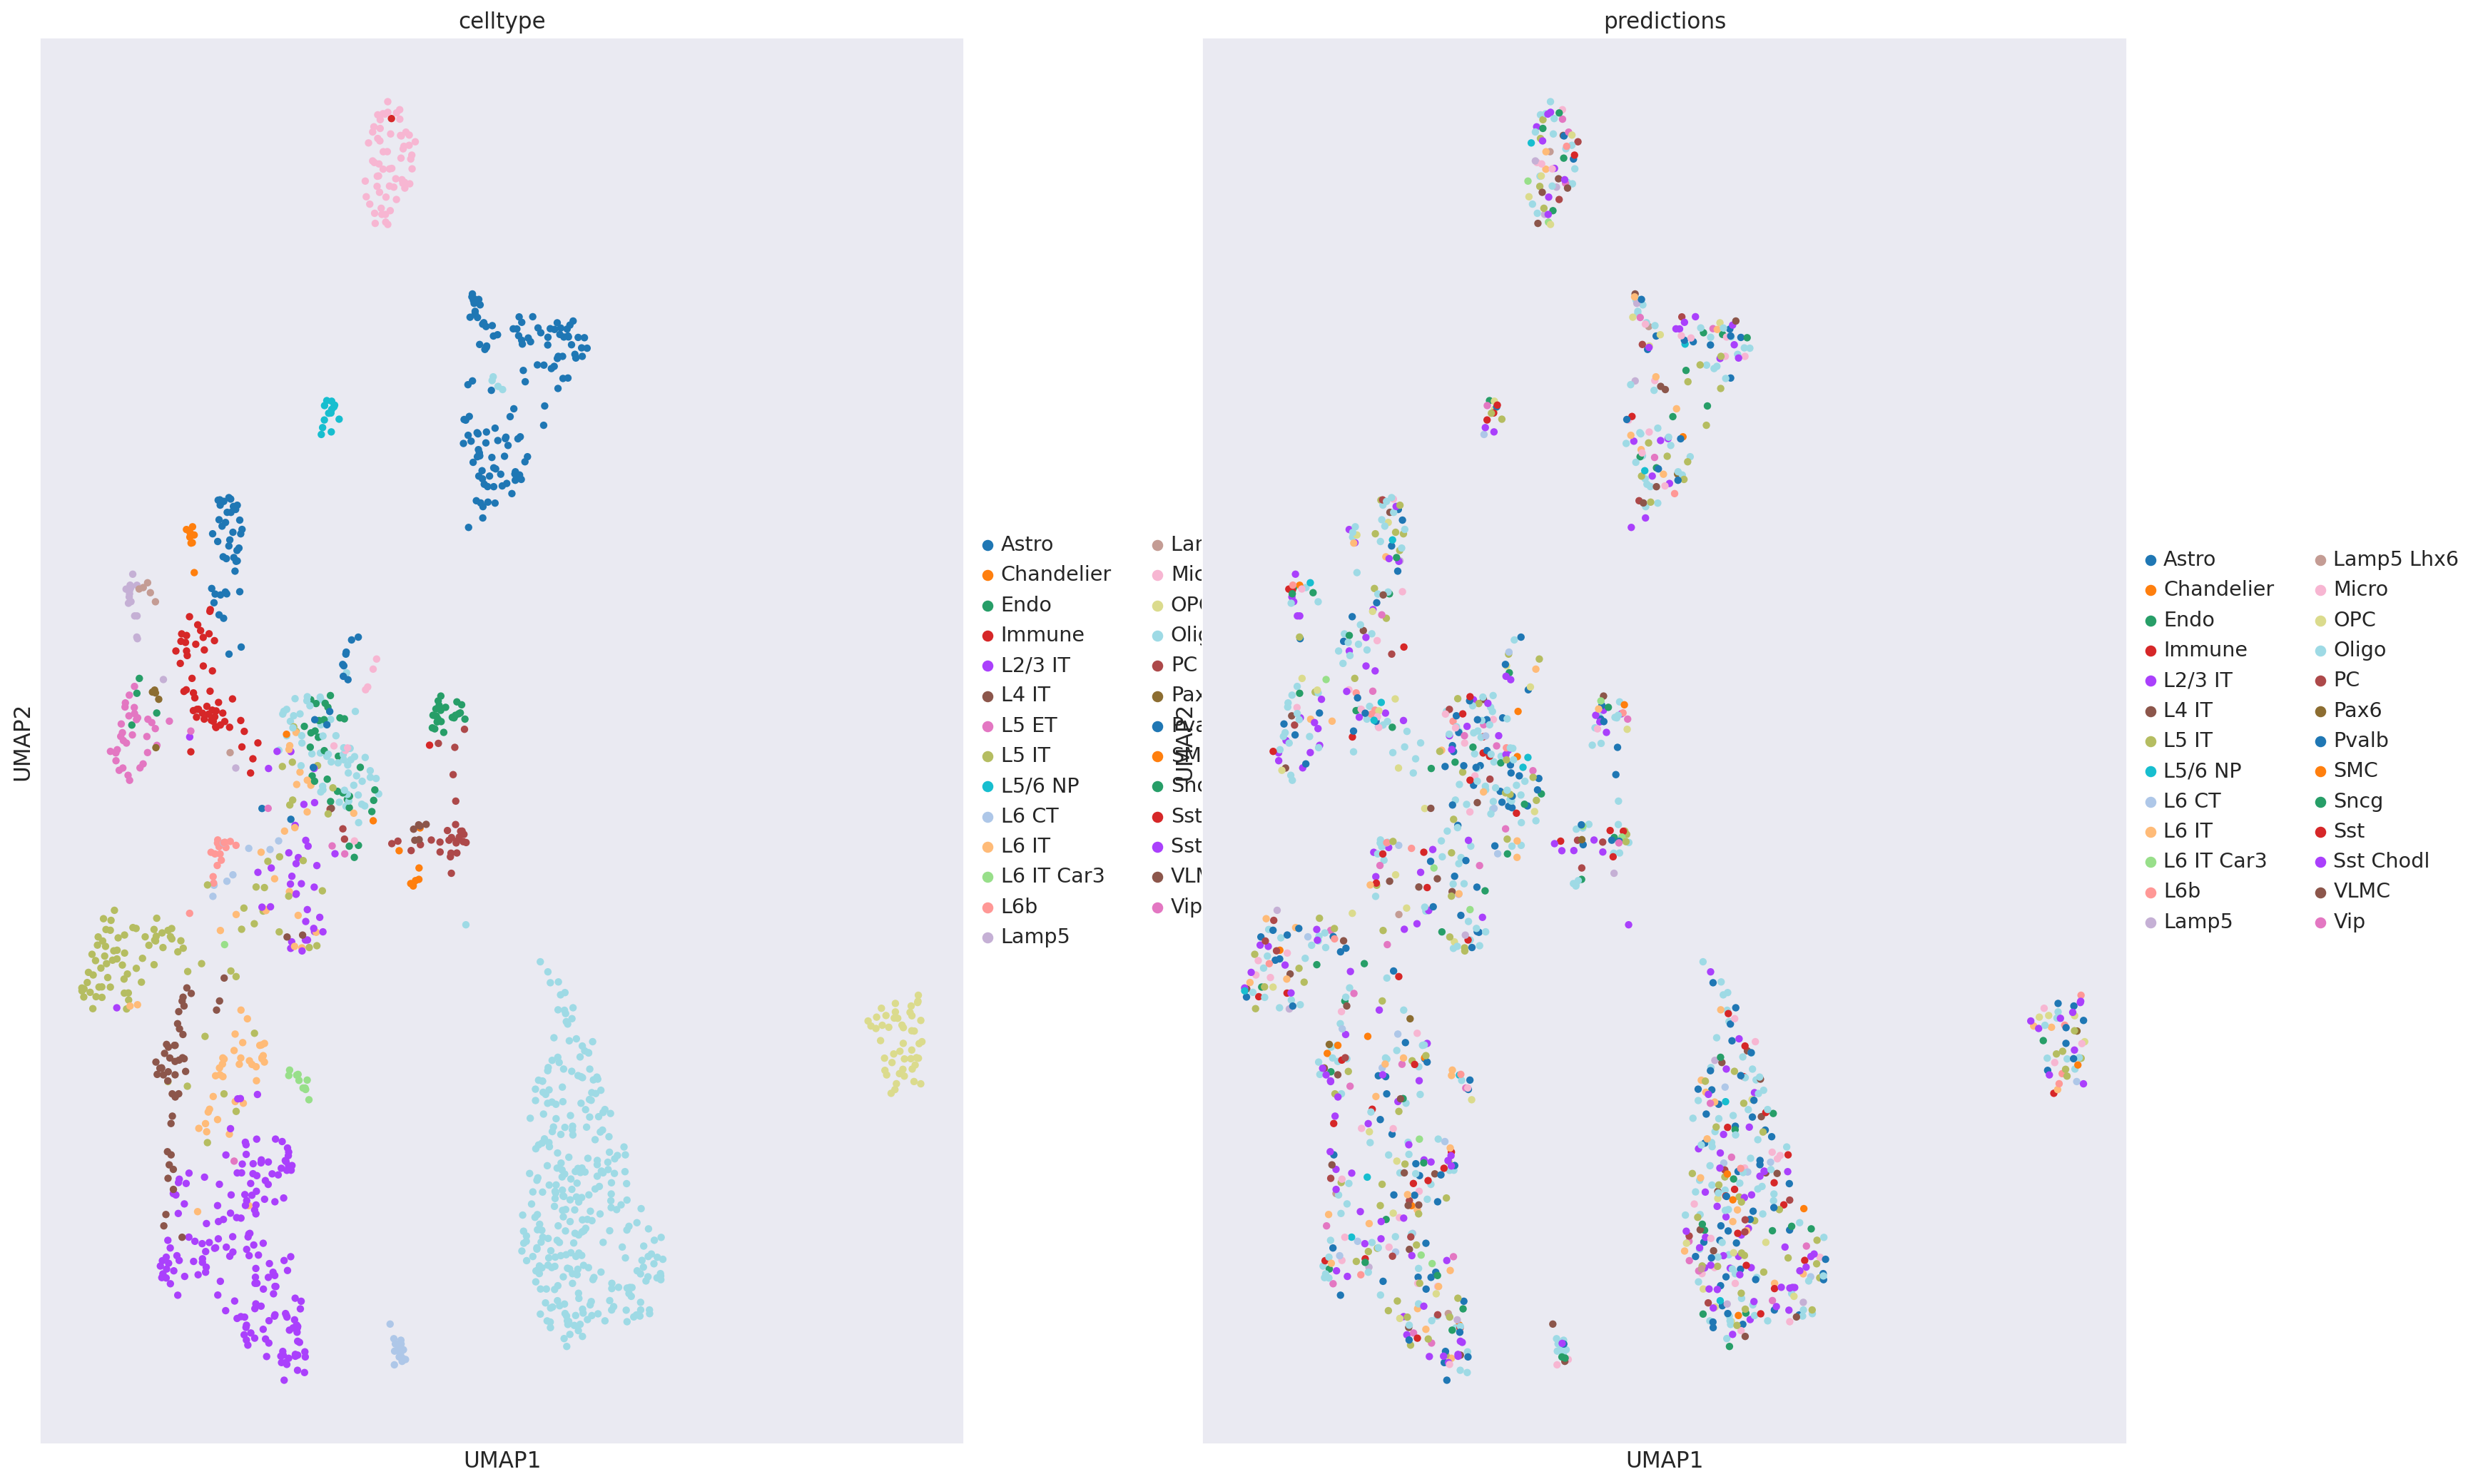

In [29]:
sc.pp.neighbors(adata_test_raw, use_rep="X")
sc.tl.umap(adata_test_raw)

# plot
base = plt.rcParams["axes.prop_cycle"].by_key()["color"]
palette_list = (base * ((num_types // len(base)) + 1))[:num_types]
palette_ = dict(zip(celltypes, palette_list))

fig = sc.pl.umap(
    adata_test_raw,
    color=["celltype", "predictions"],
    palette=palette_,
    return_fig=True,
)

fig.set_size_inches(24, 16)
fig.savefig(save_dir / "results.png", dpi=300, bbox_inches="tight")

save_dict = {
    "predictions": predictions,
    "labels": labels,
    "results": results,
    "id_maps": id2type
}
with open(save_dir / "results.pkl", "wb") as f:
    pickle.dump(save_dict, f)

results["test/cell_umap"] = wandb.Image(
    str(save_dir / "results.png"),
    caption=f"predictions macro f1 {results['test/macro_f1']:.3f}",
)
wandb.log(results)


In [30]:
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()


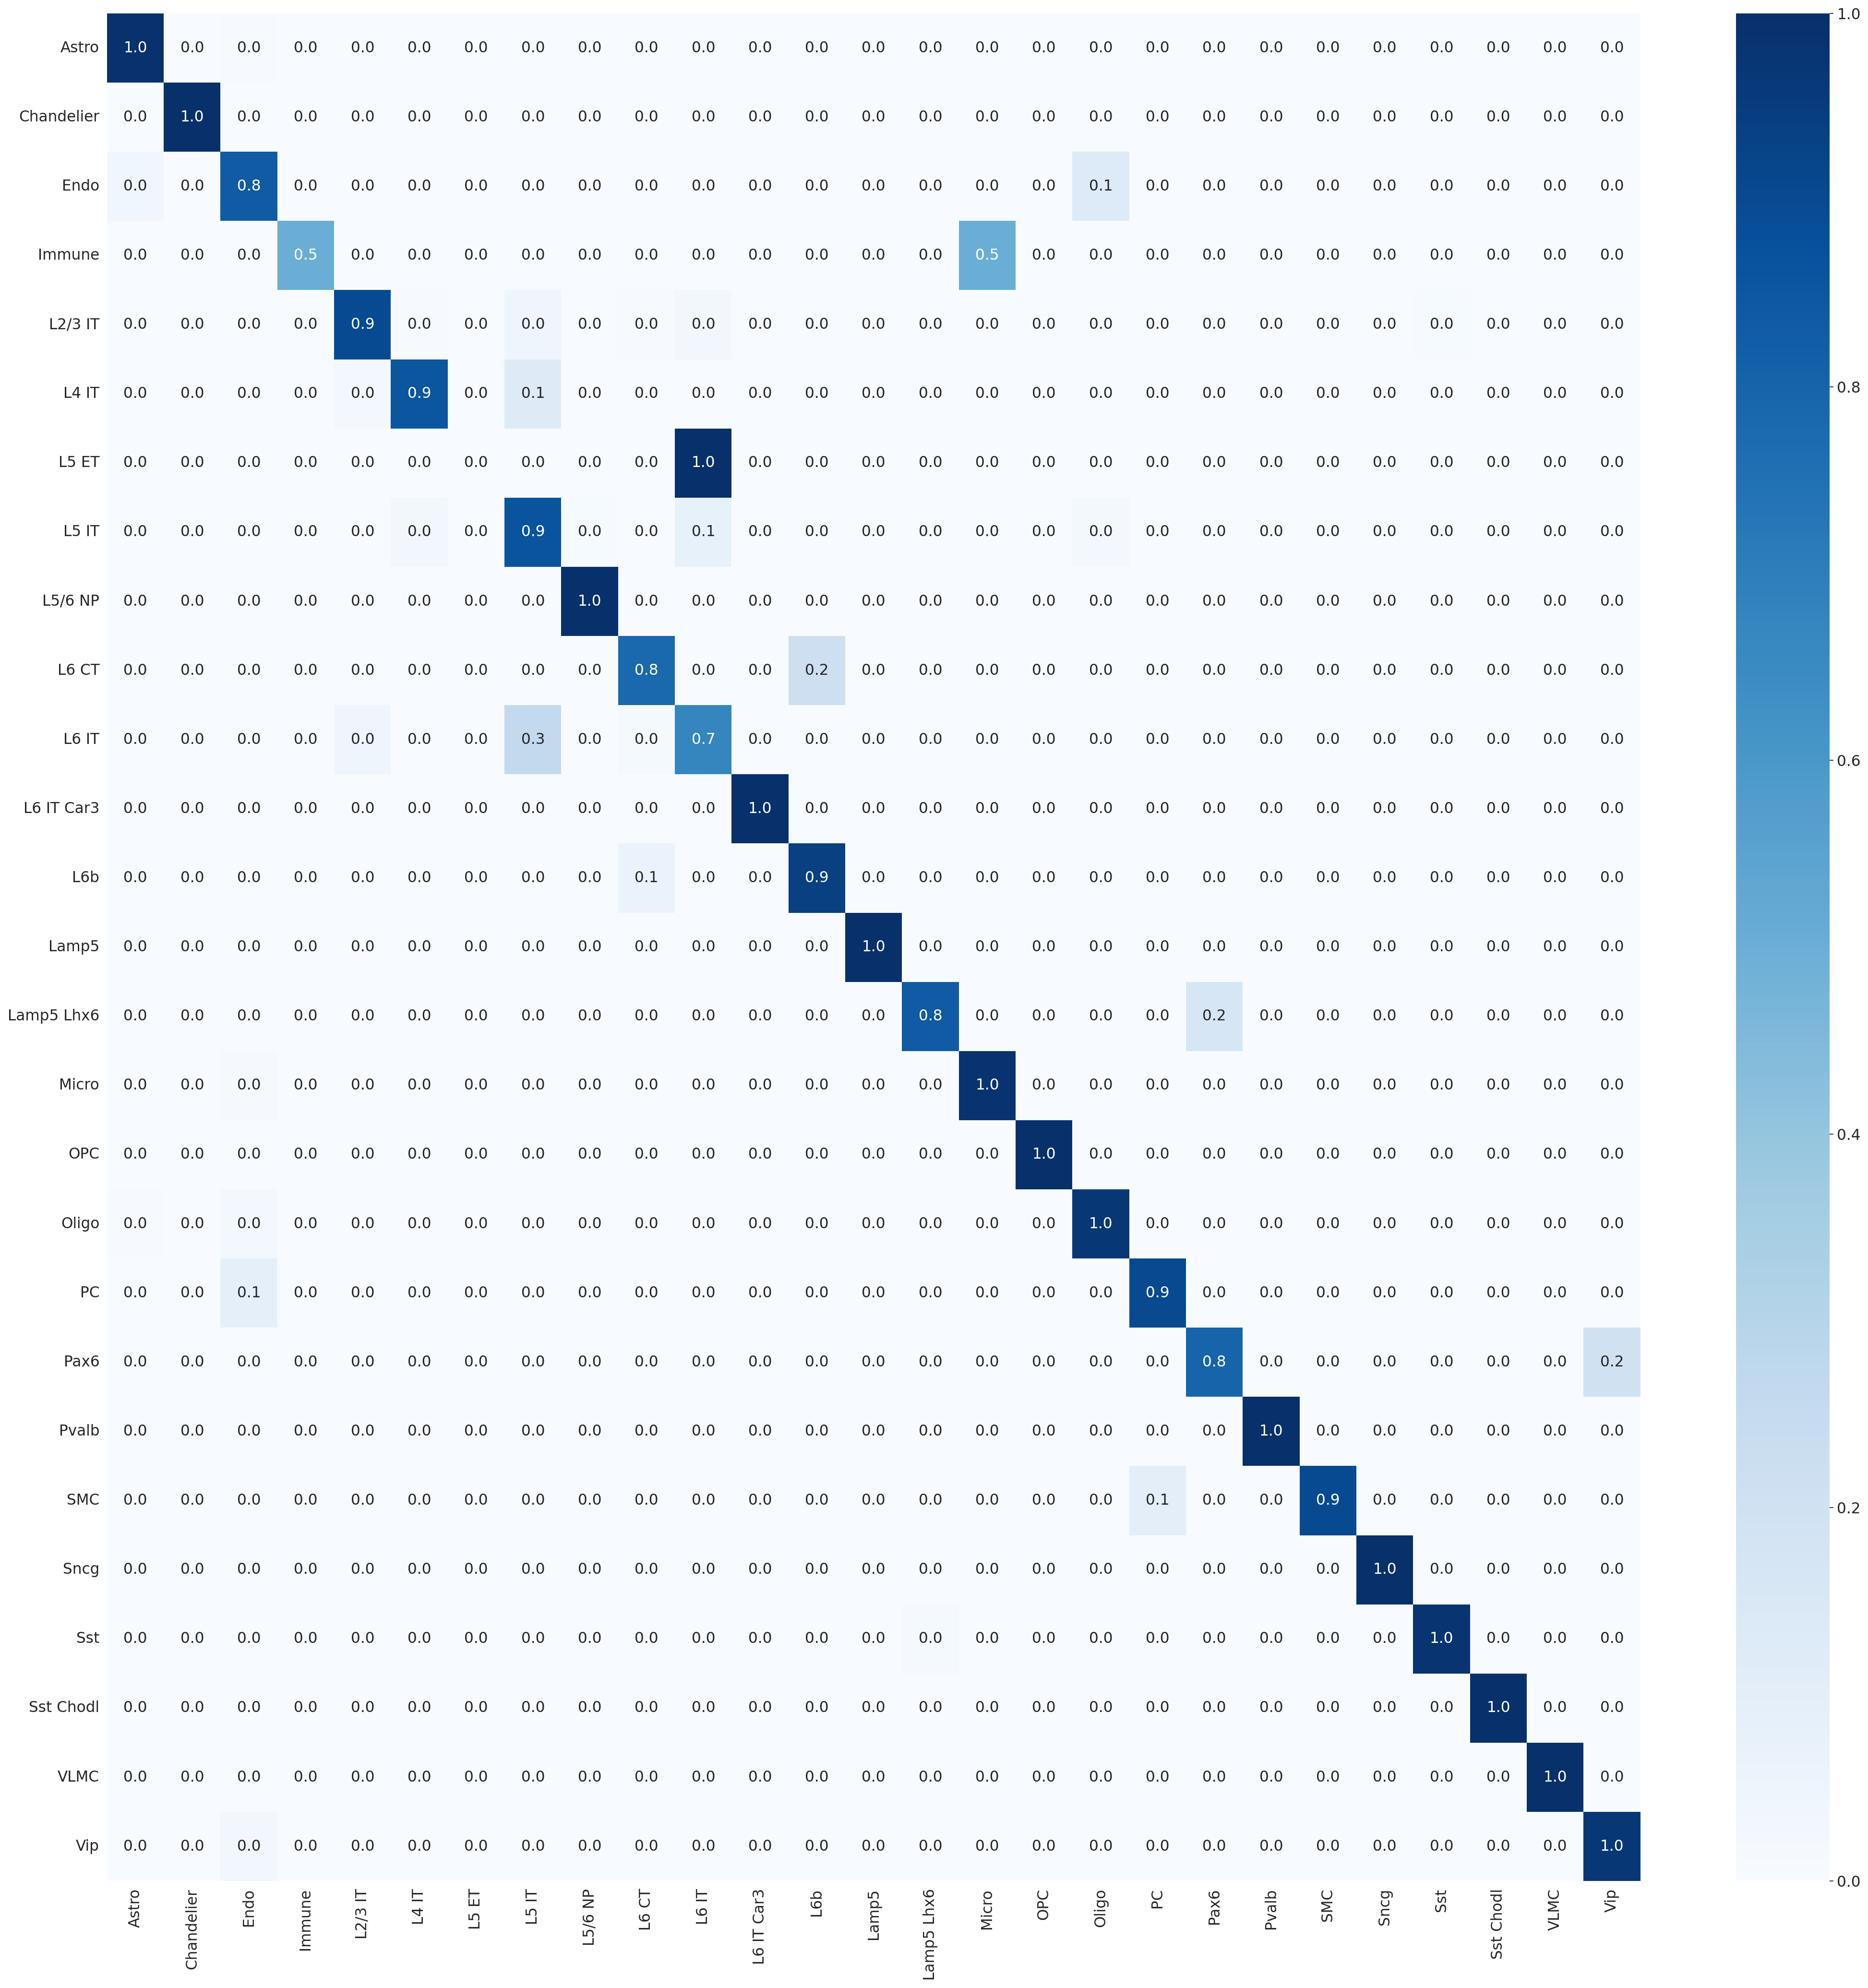

In [31]:
celltypes = list(celltypes)
for i in set([id2type[p] for p in predictions]):
    if i not in celltypes:
        celltypes.remove(i)
cm = confusion_matrix(labels, predictions)
cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
cm = pd.DataFrame(cm, index=celltypes[:cm.shape[0]], columns=celltypes[:cm.shape[1]])
plt.figure(figsize=(32, 32))
sns.heatmap(cm, annot=True, fmt=".1f", cmap="Blues")
plt.savefig(save_dir / "confusion_matrix.png", dpi=300)

results["test/confusion_matrix"] = wandb.Image(
    str(save_dir / "confusion_matrix.png"),
    caption=f"confusion matrix",
)


In [32]:
torch.save(best_model.state_dict(), save_dir / "model.pt")
